---
# <span style="color: #4169E1">**Global Tech Layoffs Analysis (2020-2024)**</span>

## <span style="color: #4169E1">**Project number 10**</span>

### <span style="color: #4169E1">Names of students:</span>  
<span style="color: #4169E1">Miriam Dinay</span><br>
<span style="color: #4169E1">Roni Shapiro</span><br>



---

#### <span style="color: #4169E1">**Project description**</span>
<span style="color: #4169E1">1-3 lines describing your project</span><br>

#### <span style="color: #4169E1">**Project description:**</span>
The dataset contains information about reported worldwide layoffs in tech companies between 2020-2024.
[link to the data source](https://www.kaggle.com/datasets/ulrikeherold/tech-layoffs-2020-2024)

<a id="intro"></a>
<h3 style="color: #4169E1; background-color: #f0f4ff; padding: 10px; border-left: 5px solid #4169E1; text-align: left; direction: ltr;">
    Introduction and Data Overview
</h3>

In [442]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [443]:
url='https://raw.githubusercontent.com/MiriamDinay/Layoff-Trends/main/tech_layoffs.csv'
Layoff_df=pd.read_csv(url)
Layoff_df.head()

,#,Company,Location_HQ,Country,Continent,Laid_Off,Date_layoffs,Percentage,Company_Size_before_Layoffs,Company_Size_after_layoffs,Industry,Stage,Money_Raised_in_$_mil,Year,lat,lng
0,3,ShareChat,Bengaluru,India,Asia,200.0,2023-12-20,15.0,1333.0,1133.0,Consumer,Series H,$1700,2023,12.97194,77.59369
1,4,InSightec,Haifa,Israel,Asia,100.0,2023-12-19,20.0,500.0,400.0,Healthcare,Unknown,$733,2023,32.81841,34.98850
2,6,Enphase Energy,San Francisco Bay Area,USA,North America,350.0,2023-12-18,10.0,3500.0,3150.0,Energy,Post-IPO,$116,2023,37.54827,-121.98857
3,7,Udaan,Bengaluru,India,Asia,100.0,2023-12-18,10.0,1000.0,900.0,Retail,Unknown,NaN,2023,12.97194,77.59369
4,14,Cruise,San Francisco Bay Area,USA,North America,900.0,2023-12-14,24.0,3750.0,2850.0,Transportation,Acquired,$15000,2023,37.77493,-122.41942


In [444]:
Layoff_df.shape

(1672, 16)

In [445]:
Layoff_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1672 entries, 0 to 1671
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   #                            1672 non-null   int64  
 1   Company                      1672 non-null   object 
 2   Location_HQ                  1672 non-null   object 
 3   Country                      1672 non-null   object 
 4   Continent                    1672 non-null   object 
 5   Laid_Off                     1565 non-null   float64
 6   Date_layoffs                 1672 non-null   object 
 7   Percentage                   1570 non-null   float64
 8   Company_Size_before_Layoffs  1511 non-null   float64
 9   Company_Size_after_layoffs   1536 non-null   float64
 10  Industry                     1672 non-null   object 
 11  Stage                        1672 non-null   object 
 12  Money_Raised_in_$_mil        1596 non-null   object 
 13  Year              

In [633]:
Layoff_df_copy = Layoff_df.copy()
Layoff_df_copy['Date_layoffs'] = pd.to_datetime(Layoff_df_copy['Date_layoffs'])
Layoff_df_copy['Money_Raised_in_$_mil'] = (Layoff_df_copy['Money_Raised_in_$_mil'].astype(str).str.replace(r'[$,]', '', regex=True))
Layoff_df_copy['Money_Raised_in_$_mil'] = pd.to_numeric(Layoff_df_copy['Money_Raised_in_$_mil'],errors='coerce')
Layoff_df_copy['#'] = Layoff_df_copy['#'].astype(str)
Layoff_df_copy = Layoff_df_copy.drop(columns=['lat', 'lng',])
Layoff_df_copy.dtypes

#                                      object
Company                                object
Location_HQ                            object
Country                                object
Continent                              object
Laid_Off                              float64
Date_layoffs                   datetime64[ns]
Percentage                            float64
Company_Size_before_Layoffs           float64
Company_Size_after_layoffs            float64
Industry                               object
Stage                                  object
Money_Raised_in_$_mil                 float64
Year                                    int64
dtype: object

In [447]:
numeric_cols = Layoff_df_copy.select_dtypes(include=['int64', 'float64']).columns
print(f'{len(numeric_cols)}\n {list(numeric_cols)}')

6
 ['Laid_Off', 'Percentage', 'Company_Size_before_Layoffs', 'Company_Size_after_layoffs', 'Money_Raised_in_$_mil', 'Year']


In [448]:
categorical_cols = Layoff_df_copy.select_dtypes(include=['object']).columns
print(f'{len(categorical_cols)}\n {list(categorical_cols)}')

7
 ['#', 'Company', 'Location_HQ', 'Country', 'Continent', 'Industry', 'Stage']


Checking for inconsistencies in the 'Year' column

In [450]:
mismatch = Layoff_df_copy[Layoff_df_copy['Date_layoffs'].dt.year != Layoff_df_copy['Year']]
mismatch.shape

(37, 14)

Overwriting the original 'Year' column with the exact year from the 'Date' column

In [452]:
Layoff_df_copy['Year'] = Layoff_df_copy['Date_layoffs'].dt.year

In [453]:
Layoff_df_copy.isnull().sum().sort_values(ascending=False)

Company_Size_before_Layoffs    161
Company_Size_after_layoffs     136
Laid_Off                       107
Percentage                     102
Money_Raised_in_$_mil           76
#                                0
Company                          0
Location_HQ                      0
Country                          0
Continent                        0
Date_layoffs                     0
Industry                         0
Stage                            0
Year                             0
dtype: int64

We chose to perform type conversion before cleaning rows to preserve the accuracy of the original data.

We decided not to impute missing values to avoid bias in the data analysis

In [455]:
Layoff_df_copy = Layoff_df_copy.dropna(subset = ['Laid_Off', 'Percentage'], how = 'all')

mask = (Layoff_df_copy['Company_Size_before_Layoffs'].notna() & Layoff_df_copy['Company_Size_after_layoffs'].notna() & Layoff_df_copy['Laid_Off'].notna())
Layoff_df_copy.loc[mask, 'size_diff_check'] = (Layoff_df_copy['Company_Size_before_Layoffs'] - Layoff_df_copy['Company_Size_after_layoffs'] - Layoff_df_copy['Laid_Off'])

print(f"Total rows after cleaning: {len(Layoff_df_copy)}")
print(Layoff_df_copy.dtypes)

Total rows after cleaning: 1624
#                                      object
Company                                object
Location_HQ                            object
Country                                object
Continent                              object
Laid_Off                              float64
Date_layoffs                   datetime64[ns]
Percentage                            float64
Company_Size_before_Layoffs           float64
Company_Size_after_layoffs            float64
Industry                               object
Stage                                  object
Money_Raised_in_$_mil                 float64
Year                                    int32
size_diff_check                       float64
dtype: object


In [456]:
Layoff_df_copy[Layoff_df_copy['size_diff_check'] != 0].shape[0]

114

Based on the analysis, it can be seen that 114 rows do not equal 0.

we conclude that there are additional factors besides layoffs that influenced the change in workforce.


In [458]:
(Layoff_df_copy.loc[mask, 'size_diff_check'] == 0).mean()

0.99933818663137

We created a copy of the original dataset, organized the data, and classified the column "types."


In [460]:
Layoff_df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1624 entries, 0 to 1671
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   #                            1624 non-null   object        
 1   Company                      1624 non-null   object        
 2   Location_HQ                  1624 non-null   object        
 3   Country                      1624 non-null   object        
 4   Continent                    1624 non-null   object        
 5   Laid_Off                     1565 non-null   float64       
 6   Date_layoffs                 1624 non-null   datetime64[ns]
 7   Percentage                   1570 non-null   float64       
 8   Company_Size_before_Layoffs  1511 non-null   float64       
 9   Company_Size_after_layoffs   1536 non-null   float64       
 10  Industry                     1624 non-null   object        
 11  Stage                        1624 non-null   obj

<h3 style="color: #4169E1; background-color: #f0f4ff; padding: 10px; border-left: 5px solid #4169E1; text-align: left; direction: ltr;">
    Question 1:
</h3>
<p dir="ltr" style="text-align: left; color: black; margin-top: 10px;">
    How did layoff patterns evolve, and which industries were the primary drivers during major peak periods?
</p>

This graph displays the total number of layoffs for each year


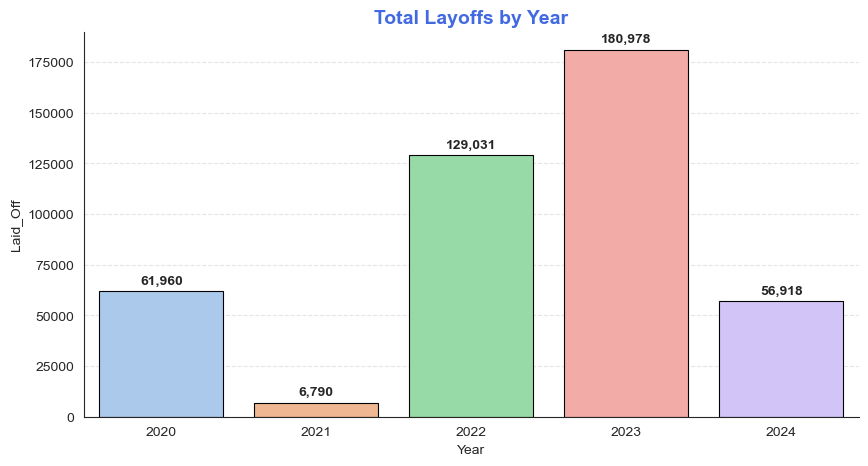

In [465]:
plt.figure(figsize=(10, 5))
yearly_layoffs=Layoff_df_copy.groupby('Year')['Laid_Off'].sum().reset_index()
sns.barplot(data=yearly_layoffs, x='Year', y='Laid_Off', palette='pastel', edgecolor='black', linewidth=0.8, hue='Year', legend=False)
plt.title('Total Layoffs by Year', fontsize=14, color='#4169E1', fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, val in enumerate(yearly_layoffs['Laid_Off']):
    plt.text(i, val+(yearly_layoffs['Laid_Off'].max()*0.02), f'{int(val):,}', ha='center', fontweight='bold')

sns.despine()
plt.show()

It can be seen that 2023 stands out as a dramatic peak year, with an increase of approximately 40% in the volume of layoffs compared to the previous year


In [531]:
row_20 = Layoff_df_copy[Layoff_df_copy['Date_layoffs'].dt.year == 2020].shape[0]
row_21 = Layoff_df_copy[Layoff_df_copy['Date_layoffs'].dt.year == 2021].shape[0]
row_22 = Layoff_df_copy[Layoff_df_copy['Date_layoffs'].dt.year == 2022].shape[0]
row_23 = Layoff_df_copy[Layoff_df_copy['Date_layoffs'].dt.year == 2023].shape[0]
row_24 = Layoff_df_copy[Layoff_df_copy['Date_layoffs'].dt.year == 2024].shape[0]
[row_20, row_21,row_22, row_23, row_24]

[333, 14, 579, 506, 192]

We break down the data by quarter to identify exactly when the most significant surges occurred


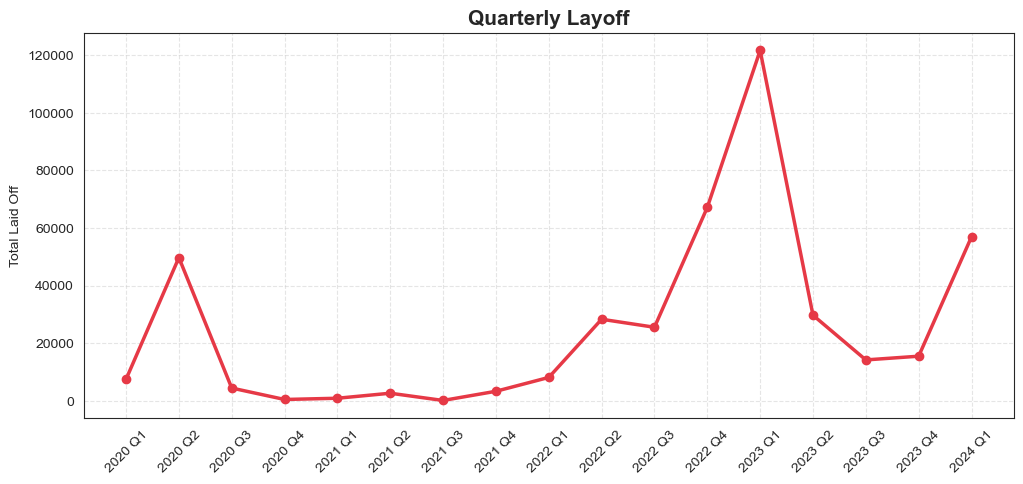

Top 3 Peaks:


,Quarter_Display,Total_Laid_Off
12,2023 Q1,121667.0
11,2022 Q4,67152.0
16,2024 Q1,56918.0


In [494]:
Layoff_df_copy['Quarter_Period'] = Layoff_df_copy['Date_layoffs'].dt.to_period('Q')
qtr_summary = (Layoff_df_copy.groupby('Quarter_Period').agg(
        Total_Laid_Off=('Laid_Off', 'sum'),
        Layoff_Events=('#', 'count')).reset_index())
qtr_summary['Quarter_Display'] = (qtr_summary['Quarter_Period'].astype(str).str.replace('Q', ' Q'))

plt.figure(figsize=(12, 5))
plt.plot(qtr_summary['Quarter_Display'], qtr_summary['Total_Laid_Off'], marker='o',linestyle='-', color='#e63946', linewidth=2.5)
plt.title('Quarterly Layoff', fontsize=15, fontweight='bold')
plt.ylabel('Total Laid Off')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

top_3_peaks = qtr_summary.sort_values('Total_Laid_Off', ascending=False).head(3)
print("Top 3 Peaks:")
display(top_3_peaks[['Quarter_Display', 'Total_Laid_Off']])

We examine the distribution of each layoff event individually. This will help us understand whether a specific quarter was dominant due to many small events or a limited number of "mass layoffs"


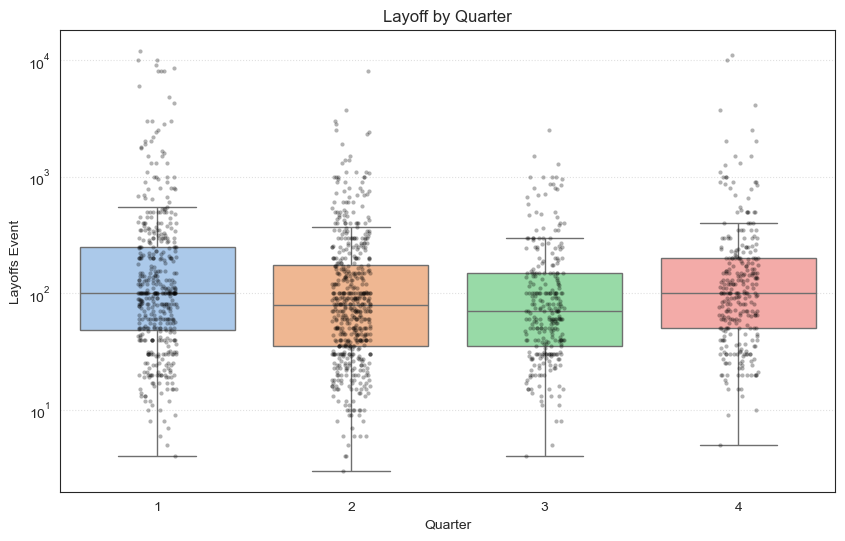

In [536]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=Layoff_df_copy.dropna(subset=['Laid_Off']), x=Layoff_df_copy['Date_layoffs'].dt.quarter, y='Laid_Off', legend=False,palette='pastel',showfliers=False, hue=quarter_data)
sns.stripplot(data=Layoff_df_copy.dropna(subset=['Laid_Off']), x=Layoff_df_copy['Date_layoffs'].dt.quarter, y='Laid_Off', color='black', size=3, alpha=0.3)

plt.yscale('log')
plt.title('Layoff by Quarter')
plt.xlabel('Quarter')
plt.ylabel('Layoffs Event')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.show()

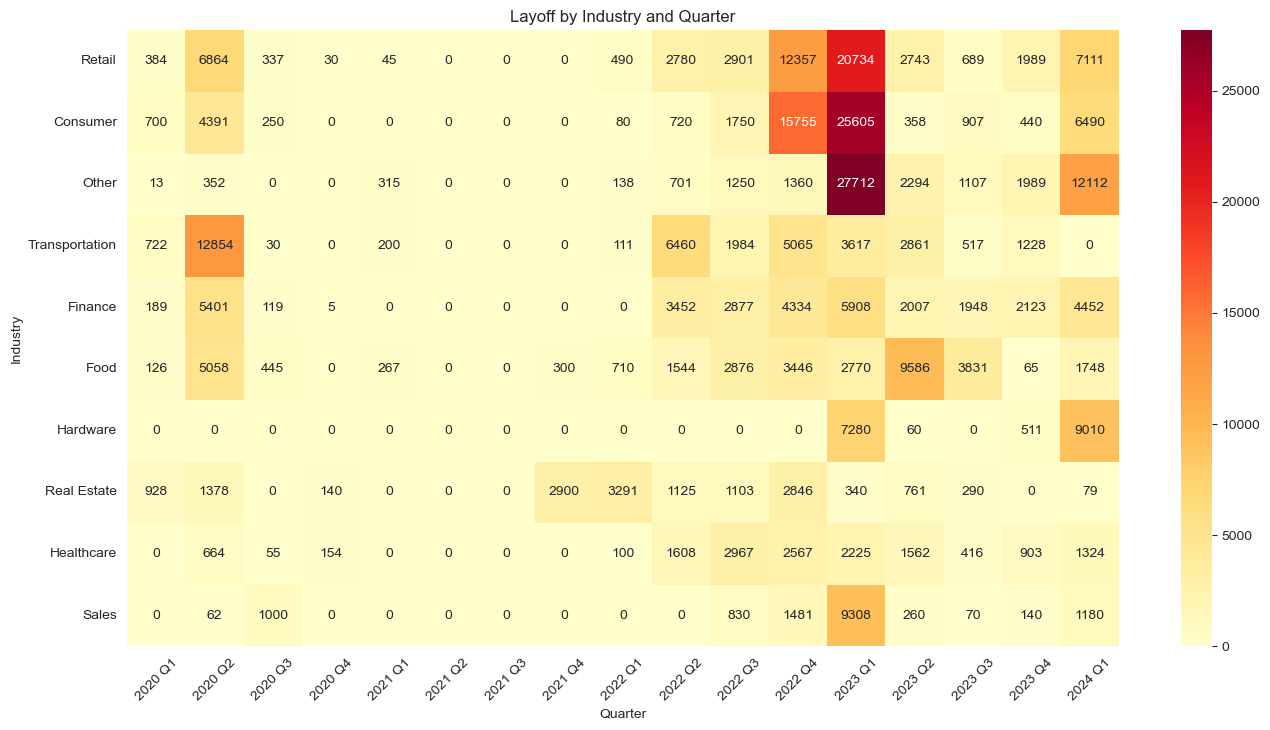

In [538]:
plt.figure(figsize=(16, 8))
sns.heatmap(industry_heatmap_df, annot=True,fmt=".0f",cmap="YlOrRd")
plt.xlabel('Quarter')
plt.ylabel('Industry')
plt.title('Layoff by Industry and Quarter')
plt.xticks(rotation=45)
plt.show()

<!-- <h4 style="color: #4169E1; text-align: left; direction: ltr;">Summary:</h4> -->
<p dir="ltr" style="text-align: left; color: black; margin-top: 10px;">
    The distributional analysis indicates that the peak layoff period in early 2023 was driven primarily by a small number of large-scale layoff events rather than a uniform increase in minor layoffs. 
    <br><br>
    This pattern is especially evident across multiple industries, suggesting that several sectors contributed jointly to the observed peak. Overall, the results highlight that major peak periods are characterized by concentrated, high-intensity layoffs rather than a higher frequency of smaller events.
</p>

<h3 style="color: #4169E1; background-color: #f0f4ff; padding: 10px; border-left: 5px solid #4169E1; text-align: left; direction: ltr;">
    Question 2:
</h3>
<p dir="ltr" style="text-align: left; color: black; margin-top: 10px;">
    How does a company's stage affect the frequency of layoffs versus their the percentage of the laid off?
</p>

In [660]:
stage_analysis_df = Layoff_df_copy.dropna(subset=['Stage', 'Laid_Off', 'Percentage']).copy()
master_stage_order = ['Seed', 'Series A', 'Series B', 'Series C', 'Series D', 'Series E', 'Series F', 'Series G', 'Series H', 'Series I', 'Series J', 'Private Equity', 'Acquired', 'Post-IPO', 'Unknown']
existing_stages = [s for s in master_stage_order if s in stage_analysis_df['Stage'].unique()]
stage_analysis_df['Stage'] = pd.Categorical(stage_analysis_df['Stage'], categories=existing_stages, ordered=True)
stage_stats = stage_analysis_df.groupby('Stage', observed=False).agg(
    Frequency=('#', 'count'), Total_Laid_Off=('Laid_Off', 'sum'), Median_Percentage=('Percentage', 'median')).reset_index()

We compare how often layoffs occur in each stage (frequency) against the total number of employees affected

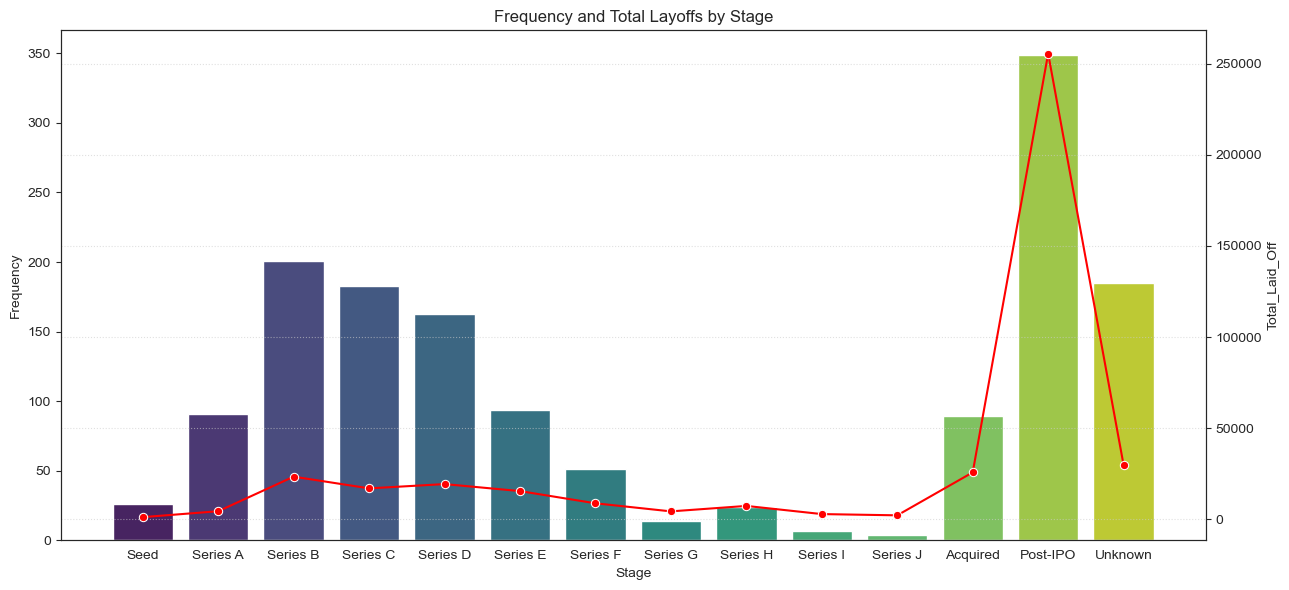

In [580]:
plt.figure(figsize=(13,6))
sns.barplot(data=stage_stats, x='Stage',y='Frequency', palette='viridis', hue='Stage')
plt.twinx()
plt.grid(axis='y', linestyle=':', alpha=0.6)
sns.lineplot(data=stage_stats, x='Stage', y='Total_Laid_Off', marker='o',color='red')
plt.title('Frequency and Total Layoffs by Stage')
plt.tight_layout()
plt.show()

<p dir="ltr" style="text-align: left; color: black; margin-top: 10px;">
    Our goal was to identify whether a specific stage is responsible for the main "mass" of layoffs in the market.
</p>

After identifying which stages experience the most layoffs, we examine the "depth of impact". We used a Boxplot to visualize the distribution of layoff percentages. This chart allows us to determine whether layoffs in smaller companies tend to be more massive relative to their size.

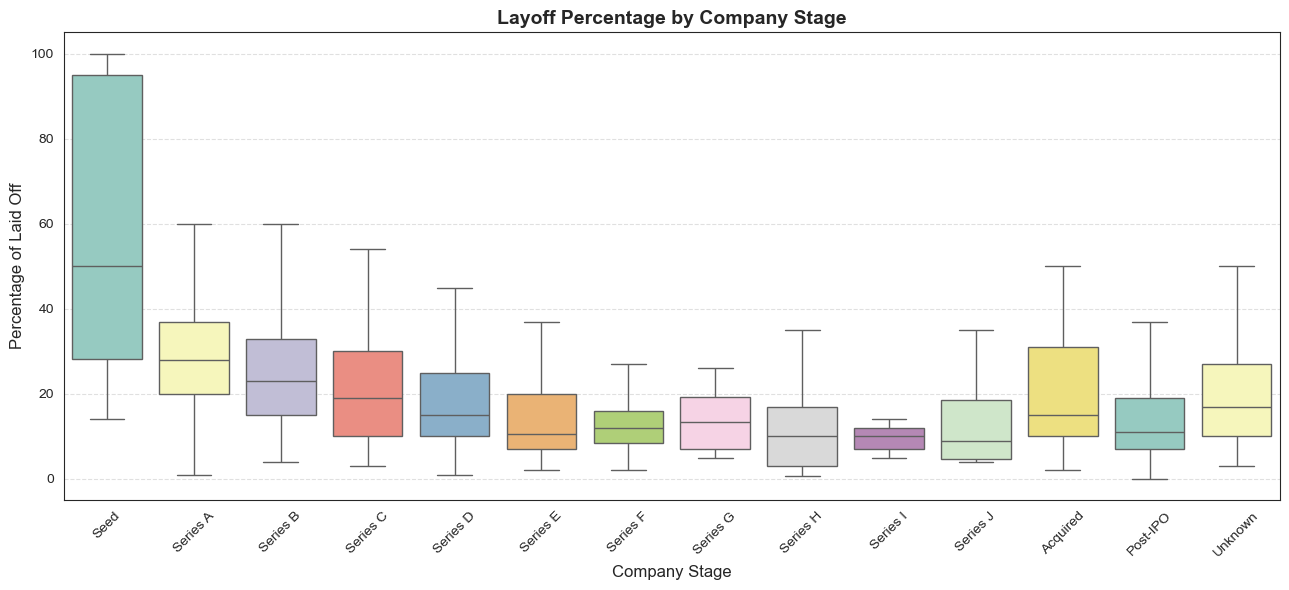

,Stage,Frequency,Total_Laid_Off,Median_Percentage
0,Seed,26,"1,178",50.0%
1,Series A,91,"4,426",28.0%
2,Series B,201,"23,406",23.0%
3,Series C,183,"16,969",19.0%
4,Series D,163,"19,318",15.0%
5,Series E,94,"15,472",10.5%
6,Series F,51,"8,770",12.0%
7,Series G,14,"4,339",13.5%
8,Series H,24,"7,331",10.0%
9,Series I,7,"2,855",10.0%


In [604]:
plt.figure(figsize=(13, 6))
sns.boxplot(data=stage_analysis_df, x='Stage', y='Percentage', palette='Set3', showfliers=False, hue='Stage', legend=False)
plt.title('Layoff Percentage by Company Stage', fontsize=14, fontweight='bold')
plt.ylabel('Percentage of Laid Off', fontsize=12)
plt.xlabel('Company Stage', fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
stage_stats.style.format({'Total_Laid_Off': '{:,.0f}', 'Median_Percentage': '{:.1f}%'}).background_gradient(cmap='Blues', subset=['Frequency', 'Total_Laid_Off']).set_caption("Summary Statistics: Company Stage Comparison")


#### Reference: Understanding Company Stages
To provide context for the ordered analysis above, the stages are categorized as follows:
* **Early Stage (Seed, Series A):** Initial funding phases for product development and early market entry.
* **Growth Stage (Series B through H):** Scaling phases where companies expand their market share and operations.
* **Late/Mature Stage (Private Equity, Acquired, Post-IPO):** Established companies that have either been bought, are managed by private investors, or are publicly traded on the stock market.

<h3 style="color: #4169E1; background-color: #f0f4ff; padding: 10px; border-left: 5px solid #4169E1; text-align: left; direction: ltr;">
    Question 3:
</h3>
<p dir="ltr" style="text-align: left; color: black; margin-top: 10px;">
    Is there a negative correlation between the total amount of money a company raised and the percentage of laid off?
</p>

In [614]:
funding_df = (Layoff_df_copy.dropna(subset=['Money_Raised_in_$_mil', 'Percentage']).loc[Layoff_df_copy['Money_Raised_in_$_mil'] >= 0])

We examine the correlation between the amounts of funding raised and the percentage of layoffs.

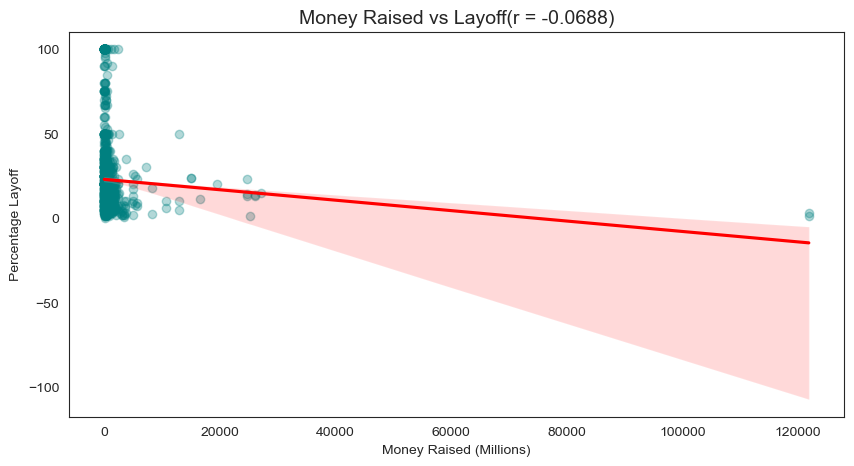

In [624]:
correlation_raw = funding_df['Money_Raised_in_$_mil'].corr(funding_df['Percentage'])

plt.figure(figsize=(10, 5))
sns.regplot(data=funding_df, x='Money_Raised_in_$_mil', y='Percentage', scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'red'})

plt.title(f'Money Raised vs Layoff(r = {correlation_raw:.4f})', fontsize=14)
plt.xlabel('Money Raised (Millions)')
plt.ylabel('Percentage Layoff')
plt.show()

To better visualize the data despite the vast gaps between values, we applied a logarithmic scale to the X-axis. This allows us to "spread out" the data points and observe that while a downward trend exists, it remains difficult to measure statistically in this manner.

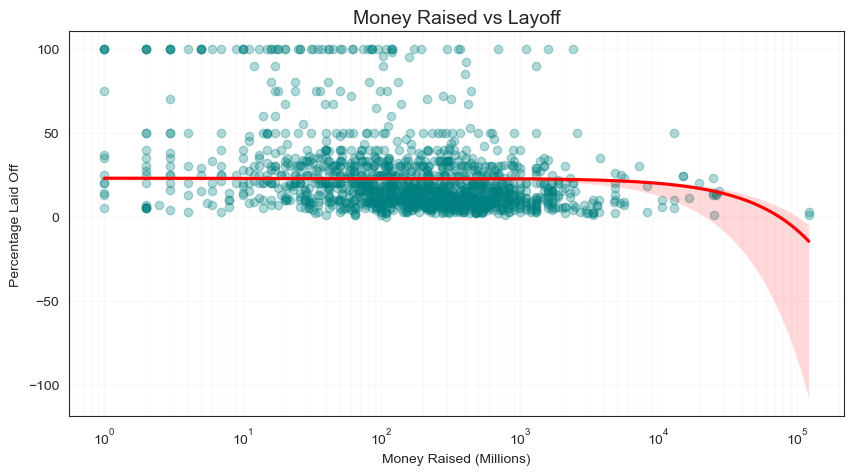

In [626]:
plt.figure(figsize=(10, 5))
sns.regplot(data=funding_df, x='Money_Raised_in_$_mil', y='Percentage', scatter_kws={'alpha':0.3, 'color':'teal'}, line_kws={'color':'red', 'label':f'Trend Line (Corr: {correlation_raw:.2f})'})

plt.xscale('log')
plt.title('Money Raised vs Layoff', fontsize=14)
plt.xlabel('Money Raised (Millions)')
plt.ylabel('Percentage Laid Off')
plt.grid(True, which="both", ls="-", alpha=0.1)
plt.show()

We perform a logarithmic transformation on the values themselves (log1p). This operation normalizes the data and allows the Pearson correlation test to calculate the true correlation. 

We discover that the correlation is significantly stronger than it initially appeared, confirming the "Safety Cushion" hypothesis.


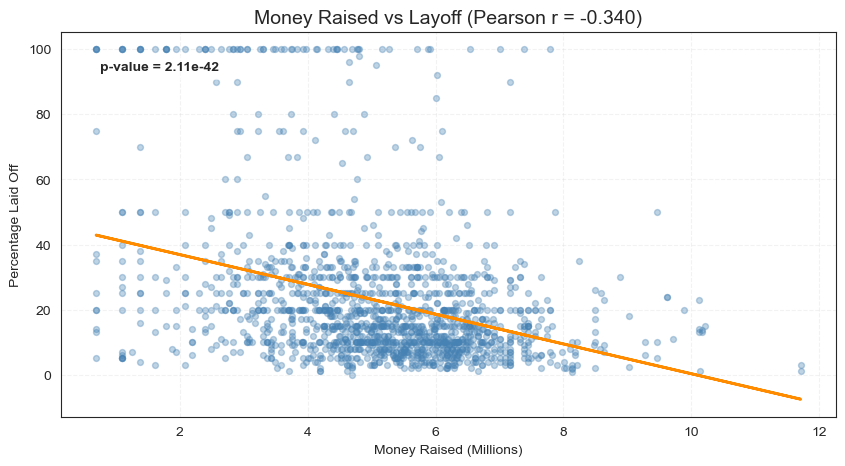

In [630]:
from scipy.stats import pearsonr
funding_df['Log_Money_Raised'] = np.log1p(funding_df['Money_Raised_in_$_mil'])
r, p = pearsonr(funding_df['Log_Money_Raised'], funding_df['Percentage'])

plt.figure(figsize=(10, 5))
plt.scatter(funding_df['Log_Money_Raised'], funding_df['Percentage'], alpha=0.35, s=18, color='steelblue')
m, b = np.polyfit(funding_df['Log_Money_Raised'], funding_df['Percentage'], 1)
plt.plot(funding_df['Log_Money_Raised'], m * funding_df['Log_Money_Raised'] + b, color='darkorange', linewidth=2)
plt.title(f'Money Raised vs Layoff (Pearson r = {r:.3f})', fontsize=14)
plt.xlabel('Money Raised (Millions)')
plt.ylabel('Percentage Laid Off')
plt.text(0.05, 0.9, f"p-value = {p:.3g}", transform=plt.gca().transAxes, fontweight='bold', bbox=dict(facecolor='white', alpha=0.5))
plt.grid(True, linestyle='--', alpha=0.25)
plt.show()

While the raw data obscured the relationship, deep analysis revealed a weak negative correlation ($r = -0.34$). 

Companies that raised significantly higher amounts (by orders of magnitude) tend to lay off a smaller percentage of their workforce, indicating greater financial resilience in the face of crises.